# Steam Game Recommender: Collaborative Filtering with PySpark ALS

**Author:** Oladiti Abdulahi

This notebook builds a game recommender system from Steam user behaviour data. It uses Spark MLlib's Alternating Least Squares (ALS) with implicit feedback, tracks experiments with MLflow, and evaluates the model with ranking metrics against a popularity baseline.

**Stack:** PySpark, Spark SQL, MLlib (ALS), MLflow, matplotlib

**Contents**
1. Setup
2. Data loading and quality checks
3. Exploratory data analysis
4. Pre-processing
5. Evaluation approach
6. Baseline: most-popular games
7. ALS experiments tracked with MLflow
8. Results
9. Example recommendations
10. Conclusions and limitations

## 1. Setup

The notebook runs on a free Google Colab runtime or any local Python environment with Java installed. PySpark runs in local mode, and MLflow logs every ALS run to a local `mlruns/` folder.

**Data:** download `steam-200k.csv` from the [Steam Video Games dataset on Kaggle](https://www.kaggle.com/datasets/tamber/steam-video-games) and upload it to the Colab session (or place it next to this notebook).

In [1]:
!pip install -q pyspark mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import mlflow
import logging
import matplotlib.pyplot as plt
import pandas as pd

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, DoubleType
from pyspark.ml.feature import StringIndexer
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RankingEvaluator

logging.getLogger("mlflow").setLevel(logging.ERROR)

spark = (
    SparkSession.builder
    .appName("steam-als-recommender")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

SEED = 42
K = 10  # number of recommendations evaluated per user
DATA_PATH = "steam-200k.csv"

# Runs are logged to ./mlruns — view them later with `mlflow ui`
mlflow.set_experiment("steam_als_recommender")

<Experiment: artifact_location='/content/mlruns/1', creation_time=1790286542276, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790286542276, lifecycle_stage='active', name='steam_als_recommender', tags={}, trace_location=None, workspace='default'>

## 2. Data loading and quality checks

The dataset is the public **Steam Video Games (steam-200k)** dataset. Each row records a user's interaction with a game:

| Column | Description |
|---|---|
| UserID | Steam user identifier |
| Game_name | Title of the game |
| Behaviour | `purchase` or `play` |
| Value | `1.0` for purchases; hours played for plays |

The file has no header row, so an explicit schema is supplied. This is faster and safer than `inferSchema`. The Kaggle version includes an extra constant fifth column, which is not needed and is ignored by the schema.

In [3]:
schema = StructType([
    StructField("UserID", IntegerType(), True),
    StructField("Game_name", StringType(), True),
    StructField("Behaviour", StringType(), True),
    StructField("Value", DoubleType(), True),
])

raw_df = spark.read.csv(DATA_PATH, header=False, schema=schema)
raw_df.show(5, truncate=False)

+---------+--------------------------+---------+-----+
|UserID   |Game_name                 |Behaviour|Value|
+---------+--------------------------+---------+-----+
|151603712|The Elder Scrolls V Skyrim|purchase |1.0  |
|151603712|The Elder Scrolls V Skyrim|play     |273.0|
|151603712|Fallout 4                 |purchase |1.0  |
|151603712|Fallout 4                 |play     |87.0 |
|151603712|Spore                     |purchase |1.0  |
+---------+--------------------------+---------+-----+
only showing top 5 rows


In [4]:
print("Total rows:  ", raw_df.count())
print("Unique users:", raw_df.select("UserID").distinct().count())
print("Unique games:", raw_df.select("Game_name").distinct().count())

# Null check across every column
raw_df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in raw_df.columns]).show()

Total rows:   200000
Unique users: 12393
Unique games: 5155
+------+---------+---------+-----+
|UserID|Game_name|Behaviour|Value|
+------+---------+---------+-----+
|     0|        0|        0|    0|
+------+---------+---------+-----+



### Duplicate records

Comparing `COUNT(*)` with `COUNT(DISTINCT Game_name)` per user shows that some interactions are recorded more than once. Exact duplicate rows are removed. Where a user has more than one `play` record for the same game, the hours are summed, so each user–game pair has a single engagement value.

In [5]:
dup_count = raw_df.count() - raw_df.dropDuplicates().count()
print(f"Exact duplicate rows: {dup_count}")

games_df = raw_df.dropDuplicates()
games_df.createOrReplaceTempView("games")

Exact duplicate rows: 707


## 3. Exploratory data analysis

The EDA answers three questions that shape the modelling decisions:

1. Which behaviour signal (purchase or play) better reflects preference?
2. How skewed are play hours?
3. How concentrated is popularity across games?

In [6]:
behaviour_counts = spark.sql("""
    SELECT Behaviour, COUNT(*) AS n
    FROM games
    GROUP BY Behaviour
    ORDER BY n DESC
""")
behaviour_counts.show()

+---------+------+
|Behaviour|     n|
+---------+------+
| purchase|128804|
|     play| 70489|
+---------+------+



### Purchases that were never played

Purchase records are always `1.0`, so they cannot tell a favourite game apart from one that was never launched. The query below measures how often that happens.

In [7]:
unplayed = spark.sql("""
    WITH purchases AS (
        SELECT DISTINCT UserID, Game_name FROM games WHERE Behaviour = 'purchase'
    ),
    plays AS (
        SELECT DISTINCT UserID, Game_name FROM games WHERE Behaviour = 'play'
    ),
    flagged AS (
        SELECT pu.UserID, pu.Game_name, pl.UserID IS NULL AS never_played
        FROM purchases pu
        LEFT JOIN plays pl
          ON pu.UserID = pl.UserID AND pu.Game_name = pl.Game_name
    )
    SELECT
        COUNT(*)                                                    AS purchased_games,
        SUM(CAST(never_played AS INT))                              AS never_played_games,
        ROUND(100 * AVG(CAST(never_played AS INT)), 1)              AS pct_never_played,
        COUNT(DISTINCT CASE WHEN never_played THEN UserID END)      AS users_with_unplayed_game,
        COUNT(DISTINCT UserID)                                      AS purchasing_users
    FROM flagged
""")
unplayed.show()

+---------------+------------------+----------------+------------------------+----------------+
|purchased_games|never_played_games|pct_never_played|users_with_unplayed_game|purchasing_users|
+---------------+------------------+----------------+------------------------+----------------+
|         128804|             58327|            45.3|                    5953|           12393|
+---------------+------------------+----------------+------------------------+----------------+



A large share of users own at least one game they never launched. Purchase data would therefore treat an unplayed game the same as a favourite one. **Play hours are used as the preference signal instead**, because they measure genuine engagement.

### Distribution of play hours

In [8]:
play_hours = games_df.filter(F.col("Behaviour") == "play").select("Value")
play_hours.describe().show()

# Exact-enough quantiles: a small relativeError is needed for tail percentiles to be accurate
q = play_hours.approxQuantile("Value", [0.5, 0.9, 0.95, 0.99], 0.0001)
print(f"Median: {q[0]:.1f}h | 90th: {q[1]:.1f}h | 95th: {q[2]:.1f}h | 99th: {q[3]:.1f}h")

+-------+-----------------+
|summary|            Value|
+-------+-----------------+
|  count|            70489|
|   mean|48.87806324391023|
| stddev|229.3352359968132|
|    min|              0.1|
|    max|          11754.0|
+-------+-----------------+

Median: 4.5h | 90th: 76.0h | 95th: 189.0h | 99th: 903.0h


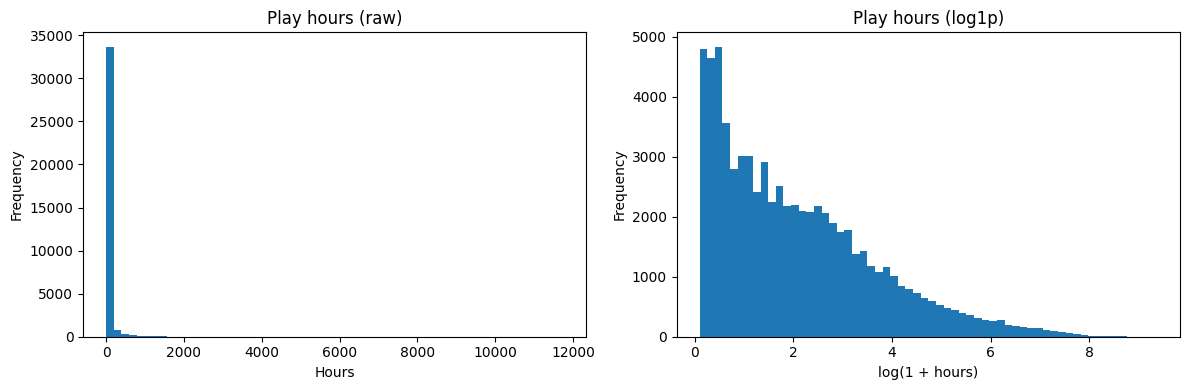

In [9]:
# Histogram of log-transformed hours (sampled to pandas for plotting)
hours_pd = play_hours.withColumn("log_hours", F.log1p("Value")).select("log_hours").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
play_hours.sample(fraction=0.5, seed=SEED).toPandas()["Value"].plot.hist(bins=60, ax=axes[0])
axes[0].set_title("Play hours (raw)")
axes[0].set_xlabel("Hours")
hours_pd["log_hours"].plot.hist(bins=60, ax=axes[1])
axes[1].set_title("Play hours (log1p)")
axes[1].set_xlabel("log(1 + hours)")
plt.tight_layout()
plt.show()

Play hours are extremely right-skewed: the median is a few hours, but the maximum is over 11,000. Left untreated, a few very heavy players would dominate the model. A `log1p` transform compresses the scale without deleting data, and turns the skewed distribution into a much more even one.

### Popularity concentration

+-------------------------------+-------+-----------+
|Game_name                      |players|total_hours|
+-------------------------------+-------+-----------+
|Dota 2                         |4841   |981685.0   |
|Team Fortress 2                |2323   |173673.0   |
|Counter-Strike Global Offensive|1377   |322772.0   |
|Unturned                       |1069   |16096.0    |
|Left 4 Dead 2                  |801    |33597.0    |
|Counter-Strike Source          |715    |96075.0    |
|The Elder Scrolls V Skyrim     |677    |70889.0    |
|Garry's Mod                    |666    |49725.0    |
|Counter-Strike                 |568    |134261.0   |
|Sid Meier's Civilization V     |554    |99821.0    |
+-------------------------------+-------+-----------+



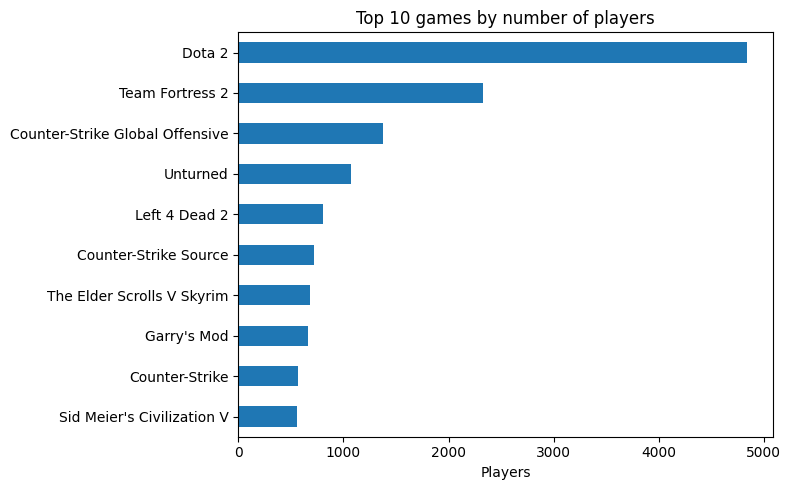

In [10]:
top_games = spark.sql("""
    SELECT Game_name,
           COUNT(DISTINCT UserID)  AS players,
           ROUND(SUM(Value), 0)    AS total_hours
    FROM games
    WHERE Behaviour = 'play'
    GROUP BY Game_name
    ORDER BY players DESC
    LIMIT 10
""")
top_games.show(truncate=False)

top_pd = top_games.toPandas().sort_values("players")
top_pd.plot.barh(x="Game_name", y="players", legend=False, figsize=(8, 5))
plt.title("Top 10 games by number of players")
plt.xlabel("Players")
plt.ylabel("")
plt.tight_layout()
plt.show()

A small group of free-to-play titles, led by Dota 2, dominates. That makes "recommend the most popular games" a strong and realistic baseline, so the ALS model has to beat it to be useful.

## 4. Pre-processing

1. **Keep play records only**, since play hours are the preference signal.
2. **Aggregate to one row per user–game pair.**
3. **Transform hours to a confidence score** with `log1p(hours)`.
4. **Create integer game IDs**, because ALS requires numeric item IDs.
5. **Split 80/20** into training and test sets.

In [11]:
interactions = (
    games_df
    .filter(F.col("Behaviour") == "play")
    .groupBy("UserID", "Game_name")
    .agg(F.sum("Value").alias("hours"))
    .withColumn("confidence", F.log1p("hours"))
)

# StringIndexer assigns an integer ID to each game (most frequent game gets 0)
indexer = StringIndexer(inputCol="Game_name", outputCol="game_idx").fit(interactions)
interactions = (
    indexer.transform(interactions)
    .withColumn("game_id", F.col("game_idx").cast("int"))
    .drop("game_idx")
    .cache()
)

game_lookup = interactions.select("game_id", "Game_name").distinct().cache()

print("User–game interactions:", interactions.count())
print("Users:", interactions.select("UserID").distinct().count())
print("Games:", game_lookup.count())
interactions.show(5, truncate=False)

User–game interactions: 70477
Users: 11350
Games: 3600
+--------+-------------------+-----+------------------+-------+
|UserID  |Game_name          |hours|confidence        |game_id|
+--------+-------------------+-----+------------------+-------+
|53875128|Assassin's Creed II|33.0 |3.5263605246161616|244    |
|53875128|Bastion            |9.6  |2.3608540011180215|128    |
|53875128|Spec Ops The Line  |4.4  |1.6863989535702286|258    |
|53875128|Dead Space         |3.3  |1.4586150226995167|224    |
|53875128|Floating Point     |1.1  |0.7419373447293773|753    |
+--------+-------------------+-----+------------------+-------+
only showing top 5 rows


In [12]:
train, test = interactions.randomSplit([0.8, 0.2], seed=SEED)
train = train.cache()
test = test.cache()
print(f"Training rows: {train.count()} | Test rows: {test.count()}")

Training rows: 56638 | Test rows: 13839


## 5. Evaluation approach

With `implicitPrefs=True`, ALS does not predict hours. It predicts a **preference score**, roughly between 0 and 1, so RMSE against hours played is not a meaningful measure. What matters is whether the model ranks the games a user actually goes on to play near the top of their list.

Each model is therefore evaluated as a top-10 recommender:

- For each test user, recommend 10 games they **did not play in the training data**.
- Compare these with the games they **actually played in the test set**.
- Measure **Precision@10**, **Recall@10** and **NDCG@10** with Spark's `RankingEvaluator`.

Only users who appear in both training and test are evaluated, because ALS cannot recommend for users it has never seen.

In [13]:
# Ground truth: games each test user actually played in the test period
eval_users = test.select("UserID").distinct().join(train.select("UserID").distinct(), "UserID")

ground_truth = (
    test.join(eval_users, "UserID")
    .groupBy("UserID")
    .agg(F.collect_set(F.col("game_id").cast("double")).alias("label"))
)
print("Users evaluated:", ground_truth.count())

train_seen = train.select("UserID", "game_id")


def top_k_excluding_seen(candidates, k=K):
    """candidates: UserID, game_id, score. Removes training games and keeps the top k per user."""
    w = Window.partitionBy("UserID").orderBy(F.col("score").desc())
    return (
        candidates
        .join(train_seen, ["UserID", "game_id"], "left_anti")
        .withColumn("rnk", F.row_number().over(w))
        .filter(F.col("rnk") <= k)
    )


def to_ranked_arrays(top_k):
    """Collects each user's recommendations into an ordered array of doubles."""
    return top_k.groupBy("UserID").agg(
        F.expr("transform(sort_array(collect_list(struct(rnk, game_id))), x -> cast(x.game_id AS double))")
        .alias("prediction")
    )


def ranking_metrics(pred_arrays):
    """Joins predictions to ground truth and returns precision, recall and NDCG at K."""
    scored = ground_truth.join(pred_arrays, "UserID", "left").withColumn(
        "prediction", F.coalesce("prediction", F.array().cast("array<double>"))
    )
    results = {}
    for metric in ["precisionAtK", "recallAtK", "ndcgAtK"]:
        evaluator = RankingEvaluator(metricName=metric, k=K, labelCol="label", predictionCol="prediction")
        results[metric] = evaluator.evaluate(scored)
    return results

Users evaluated: 3106


## 6. Baseline: most-popular games

The baseline recommends the most-played games in the training data, skipping any game the user has already played. Any useful personalised model should beat this.

In [14]:
N_CANDIDATES = 200  # enough popular games that 10 remain after removing played ones

popular = (
    train.groupBy("game_id").agg(F.countDistinct("UserID").alias("score"))
    .orderBy(F.col("score").desc())
    .limit(N_CANDIDATES)
)

baseline_candidates = eval_users.crossJoin(popular)
baseline_metrics = ranking_metrics(to_ranked_arrays(top_k_excluding_seen(baseline_candidates)))

print("Popularity baseline:", {k: round(v, 4) for k, v in baseline_metrics.items()})

Popularity baseline: {'precisionAtK': 0.0642, 'recallAtK': 0.248, 'ndcgAtK': 0.1884}


## 7. ALS experiments tracked with MLflow

The runs vary three hyperparameters:

- **rank:** number of latent factors (model capacity).
- **regParam:** regularisation strength (controls overfitting).
- **alpha:** how strongly the confidence score is trusted. This is the key parameter for implicit-feedback ALS.

Every run logs its parameters and ranking metrics to MLflow.

In [15]:
param_grid = [
    {"rank": 10, "regParam": 0.01, "alpha": 1.0},
    {"rank": 10, "regParam": 0.1,  "alpha": 10.0},
    {"rank": 20, "regParam": 0.1,  "alpha": 10.0},
    {"rank": 20, "regParam": 0.1,  "alpha": 40.0},
    {"rank": 50, "regParam": 0.1,  "alpha": 10.0},
    {"rank": 50, "regParam": 1.0,  "alpha": 40.0},
]

eval_users_cached = eval_users.cache()
results = []

for params in param_grid:
    run_name = f"ALS_rank{params['rank']}_reg{params['regParam']}_alpha{params['alpha']}"
    with mlflow.start_run(run_name=run_name):
        als = ALS(
            userCol="UserID", itemCol="game_id", ratingCol="confidence",
            implicitPrefs=True, coldStartStrategy="drop", nonnegative=True,
            maxIter=15, seed=SEED, **params,
        )
        model = als.fit(train)

        # Ask for extra candidates so 10 remain after removing already-played games
        recs = model.recommendForUserSubset(eval_users_cached, K + 50)
        candidates = recs.select("UserID", F.explode("recommendations").alias("r")).select(
            "UserID", F.col("r.game_id").alias("game_id"), F.col("r.rating").alias("score")
        )
        metrics = ranking_metrics(to_ranked_arrays(top_k_excluding_seen(candidates)))

        mlflow.log_params({**params, "maxIter": 15, "k": K})
        mlflow.log_metrics({f"{m}_{K}": v for m, v in metrics.items()})

        results.append({"run": run_name, **params, **metrics, "model": model})
        print(f"{run_name}: " + ", ".join(f"{m}={v:.4f}" for m, v in metrics.items()))

ALS_rank10_reg0.01_alpha1.0: precisionAtK=0.0701, recallAtK=0.2535, ndcgAtK=0.1889
ALS_rank10_reg0.1_alpha10.0: precisionAtK=0.0639, recallAtK=0.2374, ndcgAtK=0.1720
ALS_rank20_reg0.1_alpha10.0: precisionAtK=0.0593, recallAtK=0.2198, ndcgAtK=0.1616
ALS_rank20_reg0.1_alpha40.0: precisionAtK=0.0479, recallAtK=0.2086, ndcgAtK=0.1506
ALS_rank50_reg0.1_alpha10.0: precisionAtK=0.0500, recallAtK=0.1913, ndcgAtK=0.1423
ALS_rank50_reg1.0_alpha40.0: precisionAtK=0.0516, recallAtK=0.2111, ndcgAtK=0.1531


## 8. Results

Runs are ranked by NDCG@10, which rewards placing relevant games near the top of the list, and compared with the popularity baseline.

In [16]:
results_pd = pd.DataFrame([{k: v for k, v in r.items() if k != "model"} for r in results])
results_pd = pd.concat(
    [results_pd, pd.DataFrame([{"run": "Popularity baseline", **baseline_metrics}])],
    ignore_index=True,
).sort_values("ndcgAtK", ascending=False)

display(results_pd)

best = max(results, key=lambda r: r["ndcgAtK"])
best_model = best["model"]
lift = (best["ndcgAtK"] / baseline_metrics["ndcgAtK"] - 1) * 100
print(f"Best run: {best['run']}")
print(f"NDCG@{K}: {best['ndcgAtK']:.4f} vs baseline {baseline_metrics['ndcgAtK']:.4f} ({lift:+.1f}%)")

,run,rank,regParam,alpha,precisionAtK,recallAtK,ndcgAtK
0,ALS_rank10_reg0.01_alpha1.0,10.0,0.01,1.0,0.070122,0.253453,0.188917
6,Popularity baseline,NaN,NaN,NaN,0.064166,0.247993,0.188360
1,ALS_rank10_reg0.1_alpha10.0,10.0,0.10,10.0,0.063876,0.237356,0.171972
2,ALS_rank20_reg0.1_alpha10.0,20.0,0.10,10.0,0.059337,0.219816,0.161565
5,ALS_rank50_reg1.0_alpha40.0,50.0,1.00,40.0,0.051642,0.211118,0.153092
3,ALS_rank20_reg0.1_alpha40.0,20.0,0.10,40.0,0.047875,0.208565,0.150584
4,ALS_rank50_reg0.1_alpha10.0,50.0,0.10,10.0,0.049968,0.191291,0.142253


Best run: ALS_rank10_reg0.01_alpha1.0
NDCG@10: 0.1889 vs baseline 0.1884 (+0.3%)


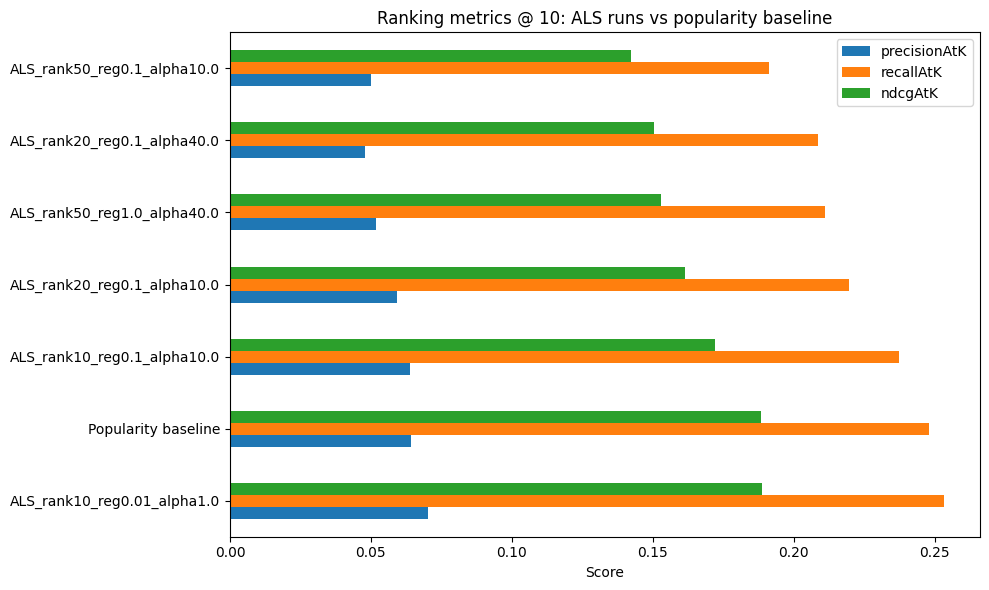

In [17]:
plot_pd = results_pd.set_index("run")[["precisionAtK", "recallAtK", "ndcgAtK"]]
plot_pd.plot.barh(figsize=(10, 6))
plt.title(f"Ranking metrics @ {K}: ALS runs vs popularity baseline")
plt.xlabel("Score")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Interpretation**

- The best configuration was **rank = 10, regParam = 0.01, alpha = 1.0**. It improved Precision@10 by about **9%** over the popularity baseline (0.070 vs 0.064) and Recall@10 by about 2% (0.253 vs 0.248). NDCG@10 was effectively tied (0.189 vs 0.188), so the gain is modest.
- **Simpler models performed better.** Increasing `alpha` from 1 to 10 to 40, or `rank` from 10 to 20 to 50, consistently lowered all three metrics. At rank 50, stronger regularisation (regParam = 1.0) partly recovered performance. Together, these results suggest larger models overfit this sparse dataset.
- **The popularity baseline is hard to beat here** because a few titles dominate play activity. A Recall@10 of about 0.25 means roughly a quarter of the games users went on to play appeared in their top 10, which is meaningful given the thousands of games available.
- Differences between the top runs are small and were not tested for statistical significance, so a wider search and cross-validation are needed before choosing a final model.

## 9. Example recommendations

   The best model is used to recommend games for one example user. Games the user has already played are removed **before** choosing the top 10, so the user always receives 10 new suggestions.

In [18]:
# Pick the evaluated user with the most games played, so there is a clear taste profile
example_user = (
    train.join(eval_users, "UserID")
    .groupBy("UserID").count()
    .orderBy(F.col("count").desc())
    .first()["UserID"]
)
print(f"Example user: {example_user}")

print("\nMost-played games (all data):")
(interactions.filter(F.col("UserID") == example_user)
    .select("Game_name", F.round("hours", 1).alias("hours"))
    .orderBy(F.col("hours").desc())
    .show(10, truncate=False))

Example user: 62990992

Most-played games (all data):
+-----------------------------------+-----+
|Game_name                          |hours|
+-----------------------------------+-----+
|Counter-Strike Global Offensive    |663.0|
|Sid Meier's Civilization V         |550.0|
|Total War SHOGUN 2                 |212.0|
|Total War ROME II - Emperor Edition|198.0|
|Dungeon Defenders                  |195.0|
|Age of Empires Online              |168.0|
|XCOM Enemy Unknown                 |126.0|
|Empire Total War                   |125.0|
|Might & Magic Heroes VI            |118.0|
|Assassin's Creed IV Black Flag     |94.0 |
+-----------------------------------+-----+
only showing top 10 rows


In [19]:
user_df = spark.createDataFrame([(example_user,)], ["UserID"])
played = interactions.filter(F.col("UserID") == example_user).select("game_id")

example_recs = (
    best_model.recommendForUserSubset(user_df, K + 50)
    .select(F.explode("recommendations").alias("r"))
    .select(F.col("r.game_id").alias("game_id"), F.col("r.rating").alias("score"))
    .join(played, "game_id", "left_anti")
    .join(game_lookup, "game_id")
    .orderBy(F.col("score").desc())
    .limit(K)
)

print("Top 10 new recommendations:")
example_recs.select("Game_name", F.round("score", 3).alias("score")).show(truncate=False)

Top 10 new recommendations:
+---------------------------------+-----+
|Game_name                        |score|
+---------------------------------+-----+
|The Binding of Isaac             |1.073|
|The Walking Dead                 |1.021|
|FTL Faster Than Light            |1.019|
|Dishonored                       |0.981|
|Dark Souls Prepare to Die Edition|0.979|
|Chivalry Medieval Warfare        |0.939|
|The Witcher Enhanced Edition     |0.93 |
|Metro 2033                       |0.912|
|Left 4 Dead                      |0.906|
|Bastion                          |0.906|
+---------------------------------+-----+



The example user mainly plays **strategy and historical games** (Civilization V, Total War: Shogun 2, Rome II and Empire, Age of Empires Online, XCOM), alongside Counter-Strike: Global Offensive.

The model recommends well-reviewed action and indie titles such as The Binding of Isaac, The Walking Dead, Dishonored and Dark Souls. Only a few, such as FTL (a strategy roguelike) and Chivalry: Medieval Warfare, closely match the user's strategy and historical focus. This reflects the **popularity bias** seen in the results: the model leans towards widely played games instead of fully personalising to niche tastes. Filtering by genre or re-ranking for diversity would be a natural next improvement.

### Targeting: which users are most likely to enjoy a given game

In [20]:
game_title = "Portal 2"  # change to any title in the dataset
target_game = game_lookup.filter(F.col("Game_name") == game_title)

(best_model.recommendForItemSubset(target_game.select("game_id"), 5)
    .select(F.explode("recommendations").alias("r"))
    .select(F.col("r.UserID").alias("UserID"), F.round("r.rating", 3).alias("score"))
    .show())

+--------+-----+
|  UserID|score|
+--------+-----+
|24632218|1.136|
|36404933|1.113|
|26762388|1.091|
|26465134|1.072|
|93275329|1.058|
+--------+-----+



## 10. Conclusions and limitations

**Approach**
- Play hours were used instead of purchases, because many purchased games are never launched.
- Hours were `log1p`-transformed to reduce the influence of extreme players without discarding data.
- ALS was trained with implicit feedback, tuned over `rank`, `regParam` and `alpha`, and tracked in MLflow.
- Models were evaluated with ranking metrics (Precision, Recall and NDCG at 10) against a most-popular baseline, rather than RMSE, which does not suit implicit-feedback models.

**Limitations and next steps**
- **Cold start:** users and games with no play history cannot receive or appear in recommendations. A content-based layer (genres, tags) could cover them.
- **Popularity bias:** a few titles dominate the data. Re-ranking for diversity or novelty could surface less obvious games.
- **Random split:** a time-based split would better reflect real use, but the dataset has no timestamps.
- **Tuning:** a wider search (e.g. with cross-validation) might find better settings.